In [1]:
!pip install -q ultralytics albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.1 MB/s eta 0:00:00


In [2]:
!pip install onnxruntime-gpu==1.20.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.5/291.5 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.4 MB/s eta 0:00:00


# Label Studio 수작업을 위한 Dataset 만들기

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ==============================================================================
# train_000 ~ train_099
# 각 영상에서 3장의 프레임 추출
#   - frame0   : 첫 프레임
#   - frame1   : 전체의 1/3 지점
#   - frame2   : 전체의 2/3 지점
# ==============================================================================
import os
import glob
import cv2

TRAIN_VID_DIR = '/content/drive/MyDrive/CONTEST/cj_box_sizing/assignment1/dataset/train'
OUT_DIR = '/content/drive/MyDrive/CONTEST/cj_box_sizing/Fine_Tuning_Dataset_rail_frames'
os.makedirs(OUT_DIR, exist_ok=True)

videos = sorted(glob.glob(os.path.join(TRAIN_VID_DIR, '*.mp4')))
print(f"총 {len(videos)}개 영상")

saved = 0
failed = []

for vp in videos:
    vid = os.path.splitext(os.path.basename(vp))[0]

    cap = cv2.VideoCapture(vp)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        print(f"❌ {vid}: 프레임 수 확인 실패")
        failed.append(vid)
        cap.release()
        continue

    # 추출할 프레임 번호
    frame_indices = [
        0,
        total_frames // 3,
        (2 * total_frames) // 3
    ]

    for idx, frame_no in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)

        ok, frame = cap.read()

        if not ok or frame is None:
            print(f"  ❌ {vid}: frame {frame_no} 읽기 실패")
            continue

        out_path = os.path.join(
            OUT_DIR,
            f"{vid}_frame{idx}.jpg"
        )

        cv2.imwrite(out_path, frame)
        saved += 1

    cap.release()

print(f"\n✅ 저장 완료: {saved}장")
if failed:
    print(f"❌ 실패: {failed}")
print(f"저장 위치: {OUT_DIR}")

In [ ]:
# ==============================================================================
# 추출한 이미지 폴더 ZIP으로 압축 후 다운로드
# ==============================================================================

import shutil
from google.colab import files

OUT_DIR = '/content/drive/MyDrive/CONTEST/cj_box_sizing/Fine_Tuning_Dataset_rail_frames'

zip_path = shutil.make_archive(
    OUT_DIR,
    'zip',
    OUT_DIR
)

print(f'ZIP 생성 완료: {zip_path}')

files.download(zip_path)

# 수작업을 마친 Dataset을 활용해서 yolov8s-seg Model Fine Tuning

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# zip 파일 경로 (본인의 경로)
zip_path = '/content/drive/MyDrive/CONTEST/cj_box_sizing/LabelStudioDataset/conveyor segment.zip'
extract_path = '/content/drive/MyDrive/CONTEST/cj_box_sizing/LabelStudioDataset_Conveyor_segment'

import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("압축 해제 완료")

압축 해제 완료


In [ ]:
import os

# 압축을 푼 경로
extract_path = '/content/drive/MyDrive/CONTEST/cj_box_sizing/LabelStudioDataset_Conveyor_segment'

print(f"--- '{extract_path}' 내부 구조 ---")

for root, dirs, files in os.walk(extract_path):
    # 경로 깊이 계산 (들여쓰기용)
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}📂 {os.path.basename(root) or 'root'}/")

    # 파일 개수 제한 (최대 2개만)
    for i, f in enumerate(files):
        if i >= 2:
            print(f"{indent}    .....")
            break
        print(f"{indent}    📄 {f}")

--- '/content/drive/MyDrive/CONTEST/cj_box_sizing/LabelStudioDataset_Conveyor_segment' 내부 구조 ---
📂 LabelStudioDataset_Conveyor_segment/
    📂 rail/
        📄 classes.txt
        📄 notes.json
        📂 labels/
            📄 train_073_frame1.txt
            📄 train_001_frame1.txt
            .....
        📂 images/
            📄 train_011_frame2.jpg
            📄 train_096_frame2.jpg
            .....


In [ ]:
# ==============================================================================
# CELL 2: 경로 설정 및 데이터셋 구조 확인
# ==============================================================================
import os

RAW_BASE_DIR   = os.path.join(extract_path, 'rail')
RAW_IMAGE_DIR  = os.path.join(RAW_BASE_DIR, 'images')
RAW_LABEL_DIR  = os.path.join(RAW_BASE_DIR, 'labels')
CLASSES_TXT    = os.path.join(RAW_BASE_DIR, 'classes.txt')

with open(CLASSES_TXT, 'r') as f:
    class_names = [line.strip() for line in f if line.strip()]

n_img = len([f for f in os.listdir(RAW_IMAGE_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
n_lbl = len([f for f in os.listdir(RAW_LABEL_DIR) if f.endswith('.txt')])

print(f"클래스 목록 : {class_names}")
print(f"이미지 수   : {n_img}")
print(f"라벨 수     : {n_lbl}")

클래스 목록 : ['0']
이미지 수   : 300
라벨 수     : 300


In [ ]:
# ==============================================================================
# CELL 3: YOLO-seg 라벨(폴리곤) 읽기/쓰기 유틸
#   - 라인 형식: class_id x1 y1 x2 y2 x3 y3 ... (모두 0~1 정규화 좌표)
# ==============================================================================
def read_yolo_seg_label(label_path):
    """
    반환: [(class_id, [(x1,y1),(x2,y2),...]), ...]
    한 이미지에 객체(폴리곤)가 여러 개일 수 있어 리스트로 반환.
    """
    objects = []
    if not os.path.exists(label_path):
        return objects
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:  # class + 최소 3점(6개 좌표)
                continue
            cls_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            pts = [(coords[i], coords[i+1]) for i in range(0, len(coords), 2)]
            objects.append((cls_id, pts))
    return objects


def write_yolo_seg_label(label_path, objects):
    with open(label_path, 'w') as f:
        for cls_id, pts in objects:
            coords_str = ' '.join(f"{x:.6f} {y:.6f}" for x, y in pts)
            f.write(f"{cls_id} {coords_str}\n")


def flip_objects_horizontal(objects):
    """폴리곤 좌표를 좌우 반전 (x -> 1-x, y는 그대로)."""
    flipped = []
    for cls_id, pts in objects:
        new_pts = [(1.0 - x, y) for (x, y) in pts]
        flipped.append((cls_id, new_pts))
    return flipped

In [ ]:
# ==============================================================================
# CELL 4: Albumentations 증강 파이프라인 정의
# ==============================================================================
import albumentations as A
import cv2
import numpy as np

pixel_aug = A.Compose([
    A.RandomBrightnessContrast(
        brightness_limit=0.15, contrast_limit=0.0, p=0.9
    ),
    A.RandomGamma(
        gamma_limit=(95, 105),  # ±5% 노출 근사
        p=0.5
    ),
    A.OneOf([
        A.Blur(blur_limit=3, p=1.0),
        A.GaussianBlur(blur_limit=(3, 3), p=1.0),
    ], p=0.3),
    A.GaussNoise(
        std_range=(0.0, 0.003),  # 0~0.3% 노이즈 근사 (255 기준 비율)
        mean_range=(0.0, 0.0),
        per_channel=True,
        p=0.4
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,     # ±10°
        sat_shift_limit=30,     # ±30%
        val_shift_limit=0,
        p=0.9
    ),
])


def apply_pixel_augmentation(image_bgr):
    """이미지에만 적용되는 색상/노이즈 계열 augmentation (좌표 영향 없음)."""
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    augmented = pixel_aug(image=rgb)['image']
    return cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)

In [ ]:
# ==============================================================================
# CELL 5: Train/Val Split (9:1, seed=42) + train만 증강본 생성 + Drive 저장
#   - Label Studio 결과물은 단일 폴더라 여기서 직접 split
# ==============================================================================
import shutil
import random

SEED = 42
VAL_RATIO = 0.1
N_AUG_PER_IMAGE = 2
FLIP_PROB = 0.5

random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = '/content/drive/MyDrive/CONTEST/cj_box_sizing'
AUG_DATASET_DIR = os.path.join(BASE_DIR, 'rail_seg_dataset_augmented')

if os.path.exists(AUG_DATASET_DIR):
    shutil.rmtree(AUG_DATASET_DIR)

TRAIN_IMG_DIR = os.path.join(AUG_DATASET_DIR, 'train', 'images')
TRAIN_LBL_DIR = os.path.join(AUG_DATASET_DIR, 'train', 'labels')
VAL_IMG_DIR   = os.path.join(AUG_DATASET_DIR, 'valid', 'images')
VAL_LBL_DIR   = os.path.join(AUG_DATASET_DIR, 'valid', 'labels')

for d in [TRAIN_IMG_DIR, TRAIN_LBL_DIR, VAL_IMG_DIR, VAL_LBL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Train/Val Split ──────────────────────────────────────────────────────────
img_files = sorted([f for f in os.listdir(RAW_IMAGE_DIR)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

shuffled = img_files.copy()
random.shuffle(shuffled)

n_val = max(1, int(round(len(shuffled) * VAL_RATIO)))
val_set = set(shuffled[:n_val])
train_files = [f for f in img_files if f not in val_set]
val_files   = [f for f in img_files if f in val_set]

print(f"전체: {len(img_files)}장 -> train: {len(train_files)}장 / val: {len(val_files)}장")

# ── VAL: 원본만 복사, 증강 없음 ──────────────────────────────────────────────
for fname in val_files:
    stem = os.path.splitext(fname)[0]
    img_path = os.path.join(RAW_IMAGE_DIR, fname)
    lbl_path = os.path.join(RAW_LABEL_DIR, stem + '.txt')

    shutil.copy(img_path, os.path.join(VAL_IMG_DIR, fname))
    objects = read_yolo_seg_label(lbl_path)
    write_yolo_seg_label(os.path.join(VAL_LBL_DIR, stem + '.txt'), objects)

# ── TRAIN: 원본 + N_AUG_PER_IMAGE 증강 ───────────────────────────────────────
for fname in train_files:
    stem = os.path.splitext(fname)[0]
    img_path = os.path.join(RAW_IMAGE_DIR, fname)
    lbl_path = os.path.join(RAW_LABEL_DIR, stem + '.txt')

    image = cv2.imread(img_path)
    if image is None:
        print(f"  ⚠️ 이미지 로드 실패: {fname}")
        continue
    objects = read_yolo_seg_label(lbl_path)

    # 원본 그대로 복사
    shutil.copy(img_path, os.path.join(TRAIN_IMG_DIR, fname))
    write_yolo_seg_label(os.path.join(TRAIN_LBL_DIR, stem + '.txt'), objects)

    # 증강본 생성
    for k in range(N_AUG_PER_IMAGE):
        aug_image = image.copy()
        aug_objects = objects

        do_flip = random.random() < FLIP_PROB
        if do_flip:
            aug_image = cv2.flip(aug_image, 1)
            aug_objects = flip_objects_horizontal(aug_objects)

        aug_image = apply_pixel_augmentation(aug_image)

        aug_fname = f"{stem}_aug{k}.jpg"
        aug_lbl_name = f"{stem}_aug{k}.txt"

        cv2.imwrite(os.path.join(TRAIN_IMG_DIR, aug_fname), aug_image)
        write_yolo_seg_label(os.path.join(TRAIN_LBL_DIR, aug_lbl_name), aug_objects)

n_train_final = len(os.listdir(TRAIN_IMG_DIR))
n_val_final   = len(os.listdir(VAL_IMG_DIR))
print(f"\n✅ 증강 완료. 저장 위치: {AUG_DATASET_DIR}")
print(f"  Train 최종: {n_train_final}장 (원본 {len(train_files)} + 증강 {len(train_files) * N_AUG_PER_IMAGE})")
print(f"  Val   최종: {n_val_final}장 (증강 없음)")

전체: 300장 -> train: 270장 / val: 30장

✅ 증강 완료. 저장 위치: /content/drive/MyDrive/CONTEST/cj_box_sizing/rail_seg_dataset_augmented
  Train 최종: 810장 (원본 270 + 증강 540)
  Val   최종: 30장 (증강 없음)


In [ ]:
# ==============================================================================
# CELL 6: 증강된 데이터셋용 data.yaml 생성
# ==============================================================================
import yaml

aug_data_yaml = {
    'train': TRAIN_IMG_DIR,
    'val':   VAL_IMG_DIR,
    'nc':    len(class_names),
    'names': class_names,
}
AUG_DATA_YAML_PATH = os.path.join(AUG_DATASET_DIR, 'data.yaml')
with open(AUG_DATA_YAML_PATH, 'w') as f:
    yaml.dump(aug_data_yaml, f, allow_unicode=True)

print("생성된 data.yaml:")
print(yaml.dump(aug_data_yaml, allow_unicode=True))

생성된 data.yaml:
names:
- '0'
nc: 1
train: /content/drive/MyDrive/CONTEST/cj_box_sizing/rail_seg_dataset_augmented/train/images
val: /content/drive/MyDrive/CONTEST/cj_box_sizing/rail_seg_dataset_augmented/valid/images



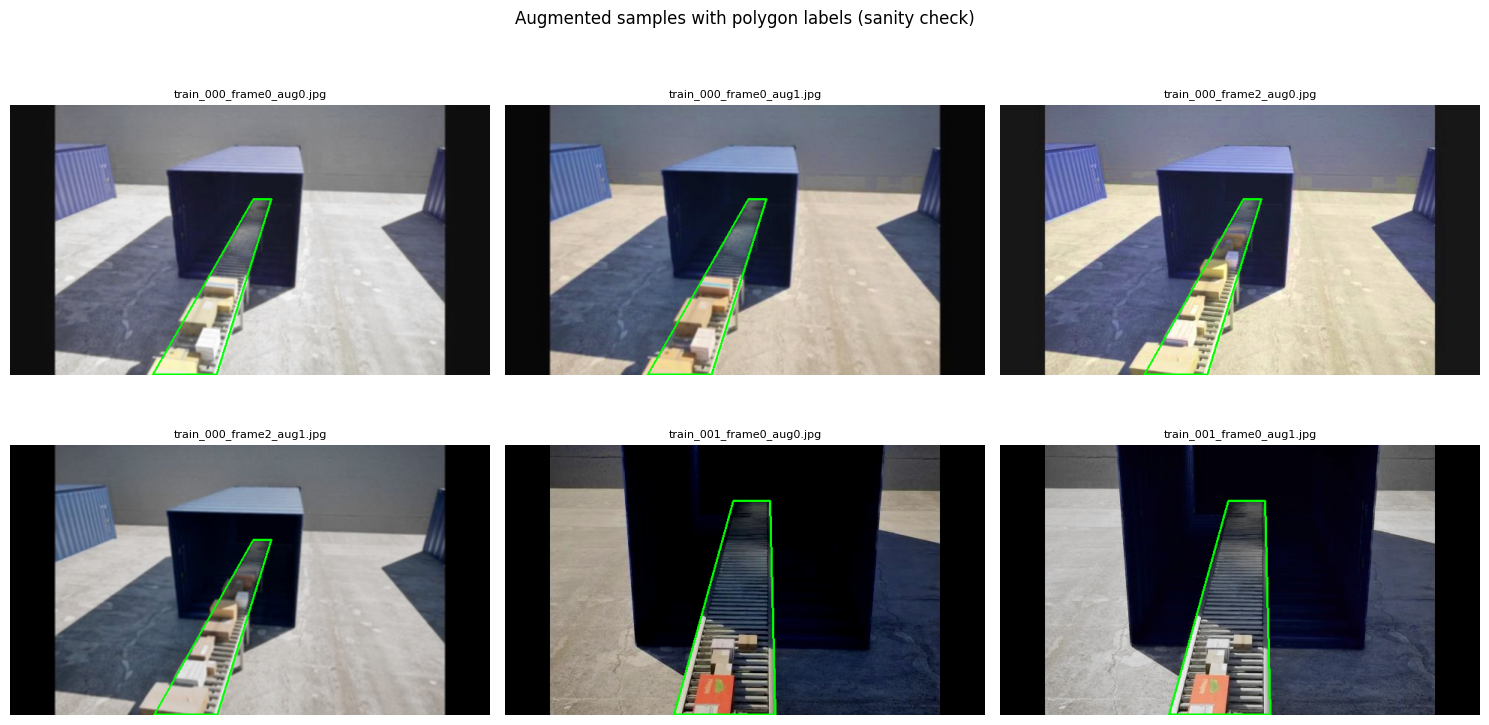

In [ ]:
# ==============================================================================
# CELL 7: 시각 검증 (증강 + 라벨이 실제로 맞물리는지 확인)
# ==============================================================================
import matplotlib.pyplot as plt

def draw_polygons(image_bgr, objects):
    disp = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).copy()
    H, W = disp.shape[:2]
    for cls_id, pts in objects:
        pts_px = np.array([[int(x*W), int(y*H)] for x, y in pts], dtype=np.int32)
        cv2.polylines(disp, [pts_px], True, (0, 255, 0), 2)
    return disp

sample_files = [f for f in os.listdir(TRAIN_IMG_DIR) if '_aug' in f][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, fname in enumerate(sample_files):
    img = cv2.imread(os.path.join(TRAIN_IMG_DIR, fname))
    lbl_path = os.path.join(TRAIN_LBL_DIR, os.path.splitext(fname)[0] + '.txt')
    objs = read_yolo_seg_label(lbl_path)
    disp = draw_polygons(img, objs)
    axes[i].imshow(disp)
    axes[i].set_title(fname, fontsize=8)
    axes[i].axis('off')
plt.suptitle("Augmented samples with polygon labels (sanity check)")
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 8: Drive -> 로컬 복사 (I/O 최적화)
# ==============================================================================
import shutil

LOCAL_DATASET_DIR = '/content/rail_seg_dataset_augmented'

if os.path.isdir(LOCAL_DATASET_DIR):
    shutil.rmtree(LOCAL_DATASET_DIR)

print("Drive → 로컬 복사 중...")
shutil.copytree(AUG_DATASET_DIR, LOCAL_DATASET_DIR)
print("복사 완료")

LOCAL_TRAIN_IMG_DIR = os.path.join(LOCAL_DATASET_DIR, 'train', 'images')
LOCAL_VAL_IMG_DIR   = os.path.join(LOCAL_DATASET_DIR, 'valid', 'images')
LOCAL_DATA_YAML     = os.path.join(LOCAL_DATASET_DIR, 'data.yaml')

# data.yaml 경로를 로컬 경로로 재작성
local_data_yaml = {
    'train': LOCAL_TRAIN_IMG_DIR,
    'val':   LOCAL_VAL_IMG_DIR,
    'nc':    len(class_names),
    'names': class_names,
}
with open(LOCAL_DATA_YAML, 'w') as f:
    yaml.dump(local_data_yaml, f, allow_unicode=True)

print(f"Train images (local) : {len(os.listdir(LOCAL_TRAIN_IMG_DIR))}장")
print(f"Val images (local)   : {len(os.listdir(LOCAL_VAL_IMG_DIR))}장")

Drive → 로컬 복사 중...
복사 완료
Train images (local) : 810장
Val images (local)   : 30장


In [ ]:
# ==============================================================================
# CELL 9: YOLOv8s-seg 학습 (로컬 데이터 + RAM 캐싱)
# ==============================================================================
from ultralytics import YOLO
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

model = YOLO('yolov8s-seg.pt')

results = model.train(
    seed=42,
    data=LOCAL_DATA_YAML,
    epochs=150,
    imgsz=640,
    batch=16,
    patience=30,
    project='/content/drive/MyDrive/CONTEST/cj_box_sizing/YOLOV8_for_RAIL_DETECT_runs',
    name='rail_seg_yolov8s_LabelStudio',
    device=0,
    optimizer='AdamW',
    lr0=1e-3,
    close_mosaic=15,
    mosaic=0.3,
    scale=0.3,
    degrees=5.0,
    fliplr=0.0,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    cache='ram',
    val=True,
    plots=True,
)

print("학습 완료. 결과 저장 위치:", results.save_dir)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rail_seg_dataset_augmented/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=rail_seg_yolov8s_LabelStudio, nbs=64, nms=False, opse

In [ ]:
# ==============================================================================
# CELL 10: 최종 모델 ONNX 변환
# ==============================================================================
best_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')

model = YOLO(best_model_path)

model.export(
    format='onnx',
    imgsz=640,
    opset=12,
    simplify=True,
    dynamic=False,
)
print("ONNX 저장 완료:", best_model_path.replace('.pt', '.onnx'))

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/CONTEST/cj_box_sizing/YOLOV8_for_RAIL_DETECT_runs/rail_seg_yolov8s_LabelStudio/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 37, 8400), (1, 32, 160, 160)) (22.7 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 256ms
Prepared 4 packages in 1.73s
Installed 4 packages in 253ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.8s
WARNING ⚠️ requirements: Restart runtime or rerun co

# 대회 제출용 requirements.txt 생성

In [12]:
# ==============================================================================
# requirements.txt 생성 (전체 pip freeze)
# ==============================================================================
import subprocess

req_path = "/content/drive/MyDrive/CONTEST/cj_box_sizing/requirements_rail_detector.txt"

result = subprocess.run(["pip", "freeze"], capture_output=True, text=True)

with open(req_path, "w") as f:
    f.write(result.stdout)

print(f"총 {len(result.stdout.splitlines())}개 패키지 저장 완료: {req_path}")
print("\n--- 미리보기 (상위 20줄) ---")
print("\n".join(result.stdout.splitlines()[:20]))

총 711개 패키지 저장 완료: /content/drive/MyDrive/CONTEST/cj_box_sizing/requirements_rail_detector.txt

--- 미리보기 (상위 20줄) ---
absl-py==1.4.0
accelerate==1.14.0
access==1.1.10.post3
affine==2.4.0
aiofiles==25.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.14.1
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.0
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.14.0
anywidget==0.9.21
apsw==3.53.2.0
